
# Week 8: Disaster Response Decision Support

## Overview
This notebook connects GeoAI outputs to **disaster response decision-making**. In earlier weeks, the focus was on building and evaluating the technical pipeline. This week shifts attention to the next question:

> **How can flood predictions support practical action?**

In real operations, a model output is only useful if it helps decision-makers:
- identify priority areas
- assess mobility disruption
- allocate response resources
- communicate severity clearly
- escalate uncertain cases for human review

This notebook demonstrates how flood severity outputs can be translated into structured decision-support summaries, action categories, and response priorities.

## Learning Objectives
- Understand how model outputs can support operational decisions
- Convert flood severity predictions into action-oriented categories
- Summarize results for emergency response teams
- Create simple prioritization logic for response planning
- Interpret uncertainty and escalation needs in a disaster context

## Expected Outcome
By the end of this notebook, you should be able to transform model predictions into a simple but meaningful decision-support workflow for flood response.



## Notebook Structure

1. Environment setup  
2. Why decision support matters  
3. Example flood prediction records  
4. Risk categories and action mapping  
5. Priority scoring  
6. Response summary dashboard tables  
7. Escalation and uncertainty handling  
8. Scenario interpretation  
9. Mini exercise  
10. Weekly assignment  

> This notebook uses synthetic but realistic operational records so students can focus on decision logic and interpretation.


In [1]:

# Week 8 setup: imports and environment check

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("Working directory:", os.getcwd())


Python version: 3.12.12
Working directory: /content


In [2]:

# Create output folder for this week

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "week08"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory ready:", OUTPUT_DIR)


Output directory ready: /content/outputs/week08



## Why Decision Support Matters

In a disaster workflow, prediction is not the final goal. The real purpose is to support better decisions.

Examples of decisions supported by flood intelligence:
- Should this road segment be considered passable?
- Which location should be inspected first?
- Which areas require traffic restriction or public warning?
- Which predictions are too uncertain to automate?

A useful response-support workflow often includes:
- **severity interpretation**
- **priority ranking**
- **recommended actions**
- **uncertainty flags**
- **human review triggers**



## Example Operational Prediction Records

The following table represents output records from an urban flood intelligence workflow. Each record corresponds to a flood-affected location or scene and contains:
- predicted flood level
- confidence
- number of vehicles observed
- whether the location is near a critical facility
- estimated access importance
- whether visibility is degraded

This is enough to build a first-pass decision-support layer.


In [3]:

# Synthetic operational records

ops_df = pd.DataFrame([
    {"location_id": "L1", "pred_level": 0, "confidence": 0.94, "vehicles_detected": 2, "near_critical_site": False, "access_importance": 2, "low_visibility": False},
    {"location_id": "L2", "pred_level": 1, "confidence": 0.85, "vehicles_detected": 4, "near_critical_site": False, "access_importance": 3, "low_visibility": False},
    {"location_id": "L3", "pred_level": 2, "confidence": 0.81, "vehicles_detected": 5, "near_critical_site": True,  "access_importance": 5, "low_visibility": False},
    {"location_id": "L4", "pred_level": 3, "confidence": 0.78, "vehicles_detected": 3, "near_critical_site": True,  "access_importance": 4, "low_visibility": True},
    {"location_id": "L5", "pred_level": 4, "confidence": 0.92, "vehicles_detected": 6, "near_critical_site": False, "access_importance": 4, "low_visibility": False},
    {"location_id": "L6", "pred_level": 2, "confidence": 0.58, "vehicles_detected": 1, "near_critical_site": False, "access_importance": 3, "low_visibility": True},
    {"location_id": "L7", "pred_level": 1, "confidence": 0.67, "vehicles_detected": 2, "near_critical_site": True,  "access_importance": 5, "low_visibility": True},
    {"location_id": "L8", "pred_level": 3, "confidence": 0.89, "vehicles_detected": 5, "near_critical_site": False, "access_importance": 4, "low_visibility": False},
    {"location_id": "L9", "pred_level": 4, "confidence": 0.63, "vehicles_detected": 3, "near_critical_site": True,  "access_importance": 5, "low_visibility": True},
    {"location_id": "L10","pred_level": 0, "confidence": 0.90, "vehicles_detected": 0, "near_critical_site": False, "access_importance": 1, "low_visibility": False},
])

ops_df


,location_id,pred_level,confidence,vehicles_detected,near_critical_site,access_importance,low_visibility
0,L1,0,0.94,2,False,2,False
1,L2,1,0.85,4,False,3,False
2,L3,2,0.81,5,True,5,False
3,L4,3,0.78,3,True,4,True
4,L5,4,0.92,6,False,4,False
5,L6,2,0.58,1,False,3,True
6,L7,1,0.67,2,True,5,True
7,L8,3,0.89,5,False,4,False
8,L9,4,0.63,3,True,5,True
9,L10,0,0.90,0,False,1,False



## Step 1: Convert Flood Levels into Risk Categories

A raw class label is not always meaningful to an emergency team.  
It is often better to map predictions into action-oriented risk language.


In [4]:

# Map predicted levels to decision-support categories

def level_to_risk(level):
    if level == 0:
        return "Minimal"
    elif level == 1:
        return "Low"
    elif level == 2:
        return "Moderate"
    elif level == 3:
        return "High"
    else:
        return "Severe"

ops_df["risk_category"] = ops_df["pred_level"].apply(level_to_risk)
ops_df[["location_id", "pred_level", "risk_category", "confidence"]]


,location_id,pred_level,risk_category,confidence
0,L1,0,Minimal,0.94
1,L2,1,Low,0.85
2,L3,2,Moderate,0.81
3,L4,3,High,0.78
4,L5,4,Severe,0.92
5,L6,2,Moderate,0.58
6,L7,1,Low,0.67
7,L8,3,High,0.89
8,L9,4,Severe,0.63
9,L10,0,Minimal,0.90



## Step 2: Recommend Actions

Next, we map risk categories into suggested actions.

These are example actions for teaching:
- **Minimal:** monitor only
- **Low:** caution advisory
- **Moderate:** field check and traffic caution
- **High:** restrict access and inspect
- **Severe:** close access and escalate


In [5]:

# Recommended action mapping

def risk_to_action(risk):
    return {
        "Minimal": "Monitor",
        "Low": "Caution advisory",
        "Moderate": "Field check + traffic caution",
        "High": "Restrict access + inspect",
        "Severe": "Close access + escalate"
    }[risk]

ops_df["recommended_action"] = ops_df["risk_category"].apply(risk_to_action)
ops_df[["location_id", "risk_category", "recommended_action"]]


,location_id,risk_category,recommended_action
0,L1,Minimal,Monitor
1,L2,Low,Caution advisory
2,L3,Moderate,Field check + traffic caution
3,L4,High,Restrict access + inspect
4,L5,Severe,Close access + escalate
5,L6,Moderate,Field check + traffic caution
6,L7,Low,Caution advisory
7,L8,High,Restrict access + inspect
8,L9,Severe,Close access + escalate
9,L10,Minimal,Monitor



## Step 3: Priority Scoring

Some locations deserve faster attention than others.  
We create a simple priority score using:
- flood severity
- prediction confidence
- number of vehicles affected
- access importance
- whether the location is near a critical site
- whether visibility is poor

This is not the only possible scoring method, but it shows how operational prioritization can be built on top of model outputs.


In [6]:

# Priority scoring function

def compute_priority_score(row):
    score = 0.0

    # Severity contribution
    score += row["pred_level"] * 2.0

    # Confidence contribution
    score += row["confidence"] * 2.0

    # Vehicle count contribution
    score += min(row["vehicles_detected"], 5) * 0.8

    # Access importance contribution
    score += row["access_importance"] * 1.5

    # Critical site bonus
    if row["near_critical_site"]:
        score += 3.0

    # Low visibility increases urgency for review/inspection
    if row["low_visibility"]:
        score += 1.5

    return round(score, 2)

ops_df["priority_score"] = ops_df.apply(compute_priority_score, axis=1)
ops_df[["location_id", "pred_level", "confidence", "priority_score"]]


,location_id,pred_level,confidence,priority_score
0,L1,0,0.94,6.48
1,L2,1,0.85,11.40
2,L3,2,0.81,20.12
3,L4,3,0.78,20.46
4,L5,4,0.92,19.84
5,L6,2,0.58,11.96
6,L7,1,0.67,16.94
7,L8,3,0.89,17.78
8,L9,4,0.63,23.66
9,L10,0,0.90,3.30


In [7]:

# Rank locations by priority

priority_df = ops_df.sort_values("priority_score", ascending=False).reset_index(drop=True)
priority_df[["location_id", "risk_category", "recommended_action", "priority_score"]]


,location_id,risk_category,recommended_action,priority_score
0,L9,Severe,Close access + escalate,23.66
1,L4,High,Restrict access + inspect,20.46
2,L3,Moderate,Field check + traffic caution,20.12
3,L5,Severe,Close access + escalate,19.84
4,L8,High,Restrict access + inspect,17.78
5,L7,Low,Caution advisory,16.94
6,L6,Moderate,Field check + traffic caution,11.96
7,L2,Low,Caution advisory,11.40
8,L1,Minimal,Monitor,6.48
9,L10,Minimal,Monitor,3.30



## Step 4: Add Escalation and Review Flags

Decision-support systems should not automate everything.  
Some predictions should be escalated for review.

Examples:
- severe risk with low confidence
- high-risk locations with low visibility
- critical-site locations with moderate or higher flood levels


In [8]:

# Escalation and human-review logic

def review_flag(row):
    if row["confidence"] < 0.65:
        return True
    if row["low_visibility"] and row["pred_level"] >= 2:
        return True
    if row["near_critical_site"] and row["pred_level"] >= 2:
        return True
    return False

def escalation_flag(row):
    if row["pred_level"] >= 4:
        return True
    if row["near_critical_site"] and row["pred_level"] >= 3:
        return True
    return False

ops_df["needs_review"] = ops_df.apply(review_flag, axis=1)
ops_df["needs_escalation"] = ops_df.apply(escalation_flag, axis=1)

ops_df[["location_id", "pred_level", "confidence", "needs_review", "needs_escalation"]]


,location_id,pred_level,confidence,needs_review,needs_escalation
0,L1,0,0.94,False,False
1,L2,1,0.85,False,False
2,L3,2,0.81,True,False
3,L4,3,0.78,True,True
4,L5,4,0.92,False,True
5,L6,2,0.58,True,False
6,L7,1,0.67,False,False
7,L8,3,0.89,False,False
8,L9,4,0.63,True,True
9,L10,0,0.90,False,False



## Step 5: Create a Decision-Support Summary

Now we summarize the output in a way that could support a response meeting or dashboard.


In [9]:

# Summary counts by risk category

risk_summary = ops_df["risk_category"].value_counts().sort_index()
risk_summary


,count
risk_category,
High,2
Low,2
Minimal,2
Moderate,2
Severe,2


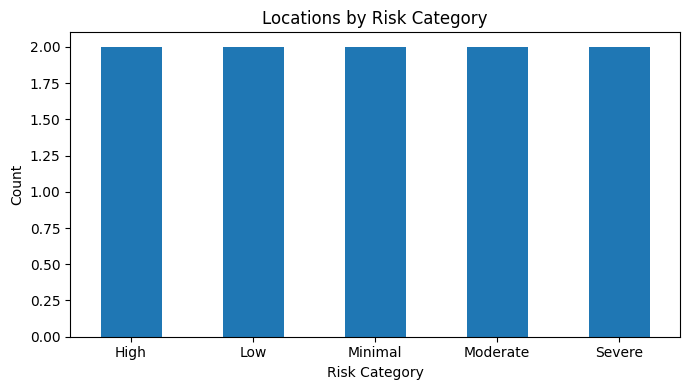

In [10]:

# Plot risk category distribution

fig, ax = plt.subplots(figsize=(7, 4))
risk_summary.plot(kind="bar", ax=ax)
ax.set_title("Locations by Risk Category")
ax.set_xlabel("Risk Category")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [11]:

# Summary counts for review and escalation

summary_flags_df = pd.DataFrame({
    "Metric": [
        "Total locations",
        "Locations needing review",
        "Locations needing escalation",
        "Critical-site locations",
        "High/Severe risk locations"
    ],
    "Value": [
        len(ops_df),
        int(ops_df["needs_review"].sum()),
        int(ops_df["needs_escalation"].sum()),
        int(ops_df["near_critical_site"].sum()),
        int((ops_df["pred_level"] >= 3).sum())
    ]
})

summary_flags_df


,Metric,Value
0,Total locations,10
1,Locations needing review,4
2,Locations needing escalation,3
3,Critical-site locations,4
4,High/Severe risk locations,4


In [12]:

# Top-priority table for response teams

top_priority = ops_df.sort_values("priority_score", ascending=False).head(5)[[
    "location_id",
    "risk_category",
    "recommended_action",
    "priority_score",
    "needs_review",
    "needs_escalation"
]]

top_priority


,location_id,risk_category,recommended_action,priority_score,needs_review,needs_escalation
8,L9,Severe,Close access + escalate,23.66,True,True
3,L4,High,Restrict access + inspect,20.46,True,True
2,L3,Moderate,Field check + traffic caution,20.12,True,False
4,L5,Severe,Close access + escalate,19.84,False,True
7,L8,High,Restrict access + inspect,17.78,False,False



## Interpretation of the Dashboard Logic

A response team might use this output to answer:
- Which locations need immediate attention?
- Which cases are safe to monitor only?
- Which areas should be restricted or closed?
- Which predictions require human confirmation before action?

This is how AI output becomes a **decision-support layer**, rather than just a technical prediction.



## Scenario Interpretation Example

Suppose a city response team receives this summary:
- several **Moderate** locations
- two **High** locations
- two **Severe** locations
- multiple locations near critical facilities
- several low-confidence or low-visibility cases

A practical response sequence may be:
1. inspect or restrict the highest-priority severe/high-risk sites
2. verify uncertain high-risk locations
3. issue advisories for moderate areas
4. continue monitoring low/minimal areas


In [13]:

# Create a concise decision-support export table

decision_export = ops_df.sort_values(
    ["needs_escalation", "priority_score"],
    ascending=[False, False]
)[[
    "location_id",
    "pred_level",
    "risk_category",
    "recommended_action",
    "priority_score",
    "needs_review",
    "needs_escalation",
    "near_critical_site",
    "low_visibility"
]]

decision_export


,location_id,pred_level,risk_category,recommended_action,priority_score,needs_review,needs_escalation,near_critical_site,low_visibility
8,L9,4,Severe,Close access + escalate,23.66,True,True,True,True
3,L4,3,High,Restrict access + inspect,20.46,True,True,True,True
4,L5,4,Severe,Close access + escalate,19.84,False,True,False,False
2,L3,2,Moderate,Field check + traffic caution,20.12,True,False,True,False
7,L8,3,High,Restrict access + inspect,17.78,False,False,False,False
6,L7,1,Low,Caution advisory,16.94,False,False,True,True
5,L6,2,Moderate,Field check + traffic caution,11.96,True,False,False,True
1,L2,1,Low,Caution advisory,11.40,False,False,False,False
0,L1,0,Minimal,Monitor,6.48,False,False,False,False
9,L10,0,Minimal,Monitor,3.30,False,False,False,False



## Optional Extension: Passability Interpretation

Another practical output is whether a road or location is likely:
- passable
- passable with caution
- restricted
- closed

This type of interpretation may be especially useful for transportation and emergency routing.


In [14]:

# Example passability logic

def passability_label(level):
    if level == 0:
        return "Passable"
    elif level == 1:
        return "Passable with caution"
    elif level == 2:
        return "Restricted"
    else:
        return "Closed"

ops_df["passability"] = ops_df["pred_level"].apply(passability_label)
ops_df[["location_id", "pred_level", "risk_category", "passability"]]


,location_id,pred_level,risk_category,passability
0,L1,0,Minimal,Passable
1,L2,1,Low,Passable with caution
2,L3,2,Moderate,Restricted
3,L4,3,High,Closed
4,L5,4,Severe,Closed
5,L6,2,Moderate,Restricted
6,L7,1,Low,Passable with caution
7,L8,3,High,Closed
8,L9,4,Severe,Closed
9,L10,0,Minimal,Passable


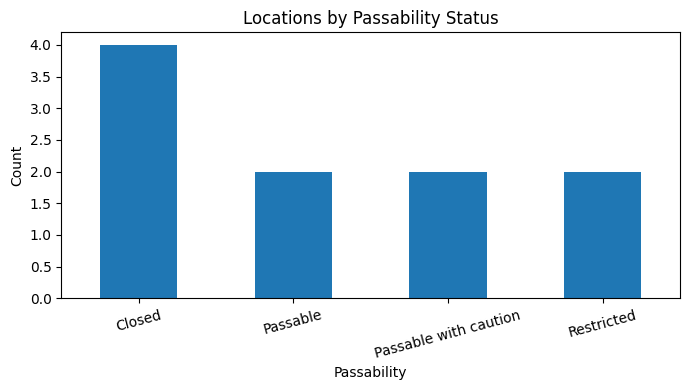

In [15]:

# Passability summary chart

passability_summary = ops_df["passability"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
passability_summary.plot(kind="bar", ax=ax)
ax.set_title("Locations by Passability Status")
ax.set_xlabel("Passability")
ax.set_ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



## Mini Exercise

Answer the following in your own words:

1. Why is a predicted flood level not enough by itself for emergency operations?
2. Why should some locations be flagged for human review even if the model provides a class label?
3. Which factor in the priority score seems most important in this notebook, and why?

Write your responses below.


In [16]:

# Write your Week 8 mini exercise responses here

# 1.
# 2.
# 3.



## Weekly Assignment

Choose one of the following:

### Option A
Write a short response-planning summary using this notebook's outputs:
- identify the top 3 priority locations
- explain the recommended actions
- identify which cases should be reviewed by humans
- explain how the team should use confidence and visibility information

### Option B
Modify the operational table by:
- adding 3 new locations
- changing some flood levels or confidence values
- recomputing the priority and review logic

Then explain how your changes affected:
- the top-priority ranking
- review and escalation counts
- passability interpretation


In [17]:

# Week 8 assignment response area

response_summary = ""
modified_scenario_notes = ""

print("Response Summary:", response_summary)
print("Modified Scenario Notes:", modified_scenario_notes)


Response Summary: 
Modified Scenario Notes: 



## Key Takeaway

The main lesson from Week 8 is:

> **A useful disaster AI system does not stop at prediction — it helps structure action.**

By translating severity estimates into risk categories, recommended actions, priority scores, and review flags, the workflow becomes much more relevant to emergency response and operational decision-making.



## Suggested Extensions

Later versions of this notebook can be expanded with:
- map-based location visualization
- travel-route impact estimation
- resource allocation simulation
- multi-day temporal updates
- uncertainty-aware dashboard logic
- links to urban digital twin systems

This keeps the notebook practical and accessible while showing how GeoAI supports real decision contexts.
